In [16]:

import os

CIRCLES_OS_PATH = 'data/circles/'
RECTANGLES_OS_PATH = 'data/rectangles/'
TRIANGLES_OS_PATH = 'data/triangles/'
MODELS_DIR = 'models/'

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

import tensorflow_model_optimization as tfmot

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

import tempfile

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

import random

import glob


# Set seed for experimental reproducibility
seed = 1
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Import Dataset

rectangle


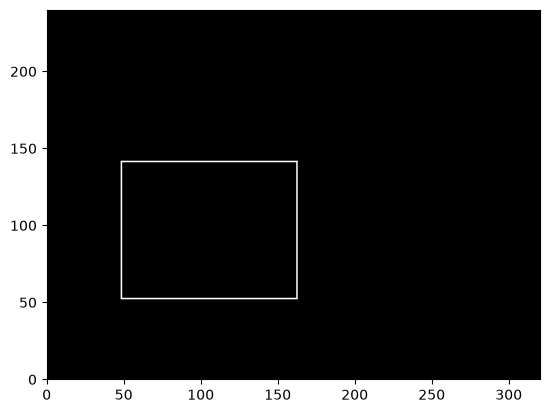

In [5]:
SAMPLES = 5000
WIDTH = 240 # Change as needed
HEIGHT = 320 # Changed as needed
np.set_printoptions(threshold=np.inf)

def show_screen(axs, screen):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,320,0,240))

label_array = ["circle", "rectangle", "triangle"]
label_to_index = dict((name, index) for index,name in enumerate(label_array))

def get_img(img_path):
    return np.load(img_path)

# Create tuple of whole dataset
def get_ds(data_path):
    labels = np.zeros(SAMPLES*3)
    images = np.zeros((SAMPLES*3, WIDTH, HEIGHT))
    img_paths = list()

    for img_path in glob.glob(F'{data_path}/**/*'):
        img_paths.append(img_path)
  
    random.shuffle(img_paths)
    for i, img_path in enumerate(img_paths):
        images[i] = get_img(img_path)
        head, tail = os.path.split(img_path)
        label_id = tail.split('-')[0]
        labels[i] = label_to_index[label_id]
    
    return images, labels


TRAIN_SPLIT = int(0.6*(SAMPLES*3))
TEST_SPLIT = int(0.2*(SAMPLES*3) + TRAIN_SPLIT)

full_x, full_y = get_ds('data')

x_train, x_test, x_validate = np.split(full_x, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(full_y, [TRAIN_SPLIT, TEST_SPLIT])

show_screen(plt, x_validate[4])
print(label_array[int(y_validate[4])])




# Create The Model

In [99]:

#model = tf.keras.Sequential([
#    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#   tf.keras.layers.Flatten(),
#    tf.keras.layers.Dense(64, activation='relu'),
#    tf.keras.layers.Dense(3)
#])


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    #tf.keras.layers.Softmax(),
    tf.keras.layers.Dense(3, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001)),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 238, 318, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 119, 159, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 117, 157, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 58, 78, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 56, 76, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 28, 38, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 17024)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │       136,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,027 (550.89 KB)

 Trainable params: 141,027 (550.89 KB)

 Non-trainable params: 0 (0.00 B)

## Train The Model

In [100]:
history = model.fit(
    x_train, y_train, epochs=10, batch_size=64, validation_data=(x_validate, y_validate)
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.6319 - loss: 0.7092 - val_accuracy: 0.7743 - val_loss: 0.4554
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.7672 - loss: 0.4858 - val_accuracy: 0.8183 - val_loss: 0.4151
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.7948 - loss: 0.4469 - val_accuracy: 0.8407 - val_loss: 0.3964
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8077 - loss: 0.4237 - val_accuracy: 0.8667 - val_loss: 0.3722
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8213 - loss: 0.4077 - val_accuracy: 0.8650 - val_loss: 0.3507
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8454 - loss: 0.3869 - val_accuracy: 0.8837 - val_loss: 0.3385
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8548 - loss: 0.3706 - val_accuracy: 0.8830 - val_loss: 0.3305
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8619 - loss: 0.3603 - 

In [101]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(F'Test Complete (Loss: {loss:.4f}, Accuracy: {acc:.4f})')

Test Complete (Loss: 0.3171, Accuracy: 0.9007)


In [102]:
def get_error(predictions, y_test):
    i = 0
    number_correct = 0
    for element in predictions:
        most_probable = max(element)
        if most_probable == element[0]:
            print(F'circle - {label_array[int(y_test[i])]}')
            if int(y_test[i]) == 0:
                number_correct += 1
        elif most_probable == element[1]:
            print(F'rectangle - {label_array[int(y_test[i])]}')
            if int(y_test[i]) == 1:
                number_correct += 1
        else:
            print(F'triangle - {label_array[int(y_test[i])]}')
            if int(y_test[i]) == 2:
                number_correct += 1
        i += 1
    print(F'Number Correct = {number_correct}/{int((SAMPLES*3)*0.2)} ({(number_correct/int((SAMPLES*3)*0.2)*100):.0f}%)')

predictions = model.predict(x_test)
get_error(predictions, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
circle - circle
triangle - triangle
rectangle - rectangle
triangle - triangle
circle - circle
rectangle - rectangle
triangle - triangle
circle - circle
triangle - triangle
rectangle - rectangle
rectangle - rectangle
triangle - triangle
triangle - triangle
triangle - triangle
circle - circle
circle - circle
rectangle - rectangle
circle - circle
rectangle - rectangle
triangle - circle
triangle - triangle
rectangle - rectangle
triangle - triangle
triangle - triangle
triangle - triangle
rectangle - rectangle
circle - circle
triangle - triangle
rectangle - rectangle
rectangle - rectangle
triangle - circle
circle - circle
rectangle - rectangle
rectangle - rectangle
triangle - triangle
triangle - circle
triangle - triangle
rectangle - rectangle
triangle - tri

# Optimize

In [103]:
model.save('models/saved_model.keras')

In [104]:
num_calibration_steps = 1
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [105]:
def representative_dataset_gen():
    for _ in range(num_calibration_steps):
        yield [tf.random.uniform(shape=(1,WIDTH,HEIGHT,1), dtype=tf.float32)]

converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tflite_quant_model2 = converter.convert()
open('models/quant_model.tflite', "wb").write(tflite_quant_model2)



INFO:tensorflow:Assets written to: C:\Users\Duckb\AppData\Local\Temp\tmp9gtgi74o\assets


INFO:tensorflow:Assets written to: C:\Users\Duckb\AppData\Local\Temp\tmp9gtgi74o\assets


Saved artifact at 'C:\Users\Duckb\AppData\Local\Temp\tmp9gtgi74o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 240, 320, 1), dtype=tf.float32, name='keras_tensor_176')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2300901816080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2300904899792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2300901814544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2300901816272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2300904899984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291676478352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291676473744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291676474128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291676479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291676475664: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Programming\python\TinyML\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


148992

In [106]:
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model2, experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_REF)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()
print(input_details)
print(output_details)

predictions = []
i = 0
for img in x_test:  
    img = img.reshape((WIDTH,HEIGHT,1))
    interpreter.set_tensor(input_details[0]['index'], [img.astype('float32')])
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predictions.append(output_data[0])
    print(F'Done {i}/{x_test.shape[0]}')
    i += 1
predictions = np.array(predictions)
get_error(predictions, y_test)

c:\Programming\python\TinyML\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[{'name': 'serving_default_keras_tensor_176:0', 'index': 0, 'shape': array([  1, 240, 320,   1], dtype=int32), 'shape_signature': array([ -1, 240, 320,   1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 28, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Done 0/3000
Done 1/3000
Done 2/3000
Done 3/3000
Done 4/3000
Done 5/3000
Done 6/3000
Done 7/3000
Done 8/3000
Done 9/3000
Done 10/3000
Done 11/3000
Done 12/3000
Done 13/3000
Done 14/3000
Done 15/3000
Done 16/3000
Done 17